## Capture Notes

Most of the capture settings used below are similar to the standard ChipWhisperer scope settings. However, there are a couple of interesting points:

- We're only capturing 129 samples (the minimum allowed with CW-lite), and the encryption is completed in less than 60 samples with an x4 ADC clock. This makes sense - as we mentioned above, our AES implementation is computing each round in a single clock cycle.
- We're using EXTCLK x4 for our ADC clock. This means that the FPGA is outputting a clock signal, and we aren't driving it.

Other than these, the last interesting setting is the number of traces. By default, the capture software is ready to capture 5000 traces - many more than were required for software AES! It is difficult for us to measure the small power spikes from the Hamming distance on the last round: these signals are dwarfed by noise and the other operations on the chip. To deal with this small signal level, we need to capture many more traces.

## Capture Setup

Setup is somewhat similar to other targets, except that we are using an external clock (driven from the FPGA-- unless you're using the CW312T-A35 target). We'll also do the rest of the setup manually:

In [1]:
import chipwhisperer as cw
scope = cw.scope()
if scope._is_husky:
    scope.adc.samples = 80
else:
    scope.adc.samples = 129
scope.adc.offset = 0
scope.adc.basic_mode = "rising_edge"
scope.trigger.triggers = "tio4"
scope.io.tio1 = "serial_rx"
scope.io.tio2 = "serial_tx"
scope.io.hs2 = "disabled"

Next, we connect to the target board and program it with the correct bitfile.

If you have a CW305, you must correctly specify the variant (either 'CW305_35t' or 'CW305_100t').

In [2]:
TARGET_PLATFORM = 'CW305_100t'

In [3]:
scope.gain.db = 25
platform = 'cw305'
fpga_id = '100t'

# On the CW305, setting force=False only programs the FPGA if it is currently unprogrammed, whereas force=True programs the FPGA regardless.
# This option isn't available on the CW312T_A35 or CW312T_ICE40.
target = cw.target(scope, cw.targets.CW305, force=False, fpga_id=fpga_id, platform=platform, bsfile="programming disabled")

(ChipWhisperer NAEUSB WARNING|File naeusb.py:800) Your firmware (0.51) is outdated - latest is 0.53 See https://chipwhisperer.readthedocs.io/en/latest/firmware.html for more information
(ChipWhisperer Target WARNING|File CW305.py:505) FPGA Bitstream not configured or 'programming disabled' not a file.


Next we set all the PLLs. We enable CW305's PLL1; this clock will feed both the target and the CW ADC. As explained [here](http://wiki.newae.com/Tutorial_CW305-1_Building_a_Project#Capture_Setup), **make sure the DIP switches on the CW305 board are set as follows**:
- J16 = 0
- K16 = 1

In [4]:
target.vccint_set(1.0)
# we only need PLL1:
target.pll.pll_enable_set(True)
target.pll.pll_outenable_set(False, 0)
target.pll.pll_outenable_set(True, 1)
target.pll.pll_outenable_set(False, 2)

# run at 10 MHz:
target.pll.pll_outfreq_set(20E6, 1)

# 1ms is plenty of idling time
target.clkusbautooff = True
target.clksleeptime = 1

In [5]:
target.fpga.FPGAProgram(open("../vivado_integration/cw305_aes.runs/impl_100t/fpga_top.bit", "rb"), exceptOnDoneFailure=False)

True

In [ ]:
import time

message = "1234567890ABCDEFGHIJKLMNOPQRTSUY"

for i in range(8):
    target.fpga_write(0, message)
    time.sleep(1)
    s = target.fpga_read(0, 32)
    print(s)
    print("Read back: {}".format(s.decode('utf-8')))

bytearray(b'1234567890ABCDEFGHIJKLMNOPQRTSUY')
Read back: 1234567890ABCDEFGHIJKLMNOPQRTSUY


CW-Husky requires a different setup when the ADC clock is driven by the target:

In [6]:
if scope._is_husky:
    scope.clock.clkgen_freq = 40e6
    scope.clock.clkgen_src = 'extclk'
    scope.clock.adc_mul = 4
    # if the target PLL frequency is changed, the above must also be changed accordingly
else:
    scope.clock.adc_src = "extclk_x4"

Finally, ensure the ADC clock is locked:

In [6]:
import time
for i in range(5):
    scope.clock.reset_adc()
    time.sleep(1)
    if scope.clock.adc_locked:
        break 
assert (scope.clock.adc_locked), "ADC failed to lock"

Occasionally the ADC will fail to lock on the first try; when that happens, the above assertion will fail (and on the CW-Lite, the red LED will be on). Simply re-running the above cell again should fix things.

## Trace Capture
Below is the capture loop. The main body of the loop loads some new plaintext, arms the scope, sends the key and plaintext, then finally records and appends our new trace to the `traces[]` list.

Because we're capturing 5000 traces, this takes a bit longer than the attacks against software AES implementations.

Note that the encryption result is read from the target and compared to the expected results, as a sanity check.

In [7]:
project_file = "projects/Tutorial_HW_CW305.cwp"
project = cw.create_project(project_file, overwrite=True)

In [8]:
from tqdm.notebook import tnrange
import numpy as np
import time
from Crypto.Cipher import AES

ktp = cw.ktp.Basic()

traces = []
textin = []
keys = []
N = 5000  # Number of traces

# initialize cipher to verify DUT result:
key, text = ktp.next()
cipher = AES.new(bytes(key), AES.MODE_ECB)

for i in tnrange(N, desc='Capturing traces'):
    # run aux stuff that should come before trace here

    key, text = ktp.next()  # manual creation of a key, text pair can be substituted here
    textin.append(text)
    keys.append(key)
    
    ret = cw.capture_trace(scope, target, text, key)
    if not ret:
        print("Failed capture")
        continue

    assert (list(ret.textout) == list(cipher.encrypt(bytes(text)))), "Incorrect encryption result!\nGot {}\nExp {}\n".format(ret.textout, list(text))
    #trace += scope.getLastTrace()
        
    traces.append(ret.wave)
    project.traces.append(ret)

Capturing traces:   0%|          | 0/5000 [00:00<?, ?it/s]

KeyboardInterrupt: 

This shows how a captured trace can be plotted:

In [10]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook

output_notebook()
p = figure(plot_width=800)

xrange = range(len(traces[0]))
p.line(xrange, traces[0], line_color="red")
show(p)

Loading BokehJS ...

AttributeError: unexpected attribute 'plot_width' to figure, similar attributes are outer_width, width or min_width

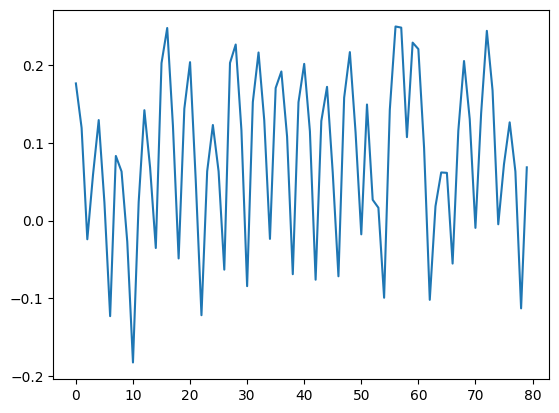

In [12]:
from matplotlib import pyplot as plt

plt.plot(traces[0])

Finally we save our traces and disconnect. By saving the traces, the attack can be repeated in the future without having to repeat the trace acquisition steps above.

In [13]:
project.save()
scope.dis()
target.dis()

(ChipWhisperer Scope ERROR|File naeusbchip.py:112) Scope already disconnected!


## Attack
Now we re-open our saved project and specify the attack parameters. For this hardware AES implementation, we use a different leakage model and attack than what is used for the software AES implementations.

Note that this attack requires only the ciphertext, not the plaintext.

In [14]:
import chipwhisperer as cw
import chipwhisperer.analyzer as cwa
project_file = "projects/Tutorial_HW_CW305"
project = cw.open_project(project_file)
attack = cwa.cpa(project, cwa.leakage_models.last_round_state_diff)
cb = cwa.get_jupyter_callback(attack)

This runs the attack:

In [15]:
attack_results = attack.run(cb)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
PGE=,0,0,0,0,0,0,0,0,0,0,0,0,0,5,0,0
0,D00.066,140.084,F90.091,A80.095,C90.084,EE0.072,250.078,890.087,E10.102,3F0.081,0C0.102,C80.067,B60.103,300.052,0C0.096,A60.073
1,F20.061,CC0.062,AC0.066,3A0.061,0F0.061,590.057,900.070,D40.058,040.064,C60.058,6C0.060,A20.059,120.057,480.052,580.062,150.059
2,430.056,7F0.061,2D0.052,0E0.058,FB0.054,EA0.056,4E0.062,D50.056,070.059,850.056,380.059,B20.056,C00.054,3C0.051,330.057,E60.056
3,0F0.052,260.053,670.051,DD0.058,FD0.052,A80.055,AE0.058,BF0.056,0A0.056,B80.054,9C0.056,B30.056,890.053,330.050,2D0.054,620.052
4,800.052,A20.053,C30.051,7B0.057,180.051,330.054,BB0.053,640.055,140.055,440.053,B50.055,2C0.055,720.052,6A0.050,FF0.054,420.051


The attack results can be saved for later viewing or processing without having to repeat the attack:

In [16]:
import pickle
pickle_file = project_file + ".results.pickle"
pickle.dump(attack_results, open(pickle_file, "wb"))

You may notice that we didn't get the expected key from this attack, but still got a good difference in correlation between the best guess and the next best guess. This is because we actually recovered the key from the last round of AES. We'll need to use analyzer to get the actual AES key: 

In [17]:
from chipwhisperer.analyzer.attacks.models.aes.key_schedule import key_schedule_rounds
recv_lastroundkey = [kguess[0][0] for kguess in attack_results.find_maximums()]
recv_key = key_schedule_rounds(recv_lastroundkey, 10, 0)
for subkey in recv_key:
    print(hex(subkey))

0xcd
0x20
0xc4
0xfe
0xb9
0xae
0xc9
0xcc
0x34
0xf7
0x83
0xc6
0xb4
0x9c
0x7a
0x11


## Tests
Check that the key obtained by the attack is the key that was used.
This attack targets the last round key, so we have to roll it back to compare against the key we provided.

In [18]:
key = list(key)
assert (key == recv_key), "Failed to recover encryption key\nGot:      {}\nExpected: {}".format(recv_key, key)

AssertionError: Failed to recover encryption key
Got:      [205, 32, 196, 254, 185, 174, 201, 204, 52, 247, 131, 198, 180, 156, 122, 17]
Expected: [43, 126, 21, 22, 40, 174, 210, 166, 171, 247, 21, 136, 9, 207, 79, 60]

## Next steps

The `jupyter/demos/CW305_ECC/` folder contains a series of tutorials for attacking hardware ECC on the CW305.

This CW305 appnote contains additional details on the CW305 platform: http://media.newae.com/appnotes/NAE0010_Whitepaper_CW305_AES_SCA_Attack.pdf